# CelebAMask-HQ Segmentation Certification Analysis

1. Class colour legend (19 classes)
2. Baseline inference results (clean images, 100 test images)
3. Isotropic certification results (all σ)
4. Manifold certification results (all σ)
5. Figures: accuracy, mIoU, certified radius, abstain rate vs σ
6. Per-class IoU tables

In [9]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import to_rgba
from scipy.stats import norm as _norm

# ── Academic style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.titlesize':    13,
    'legend.fontsize':   9,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

# ── Colorblind-safe semantic palette ─────────────────────────────────────────
C = {
    'manifold':   '#2166ac',   # blue   — solid line
    'isotropic':  '#d95f02',   # orange — dashed line
    'overall':    '#636363',   # grey
    'ood_border': '#1a9850',
}
LS   = {'Manifold': '-',   'Isotropic': '--'}
COL  = {'Manifold': C['manifold'], 'Isotropic': C['isotropic']}

# ── Paths ──────────────────────────────────────────────────────────────────────
REPO_ROOT    = Path(os.path.abspath('..'))
OUTPUT       = REPO_ROOT / 'output'
BASELINE_DIR = OUTPUT / 'segmentation' / 'celebahq' / 'baseline'
CERTIFY_DIR  = OUTPUT / 'segmentation' / 'celebamaskhq' / 'certify'

SIGMA_VALUES = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
def sigma_tag(v): return f'sigma_{v:.2f}'.replace('.','_')
def load_json(p):
    if not Path(p).exists(): return None
    return json.loads(Path(p).read_text())

# ── CelebAMask-HQ 19-class definitions ────────────────────────────────────────
CLASS_NAMES = [
    'background','skin','l_brow','r_brow','l_eye','r_eye',
    'eye_g','l_ear','r_ear','ear_r','nose','mouth',
    'u_lip','l_lip','neck','neck_l','cloth','hair','hat',
]
# RGB palette (matches SEG_PALETTE in celebahq_segmentation.py)
SEG_PALETTE_RGB = [
    (0,0,0),(255,0,0),(255,85,0),(255,170,0),(255,0,85),(255,0,170),
    (0,255,0),(85,255,0),(170,255,0),(0,255,85),(0,255,170),(0,0,255),
    (85,0,255),(170,0,255),(0,85,255),(0,170,255),(255,255,0),(255,0,255),(0,255,255),
]
SEG_HEX = ['#%02x%02x%02x' % rgb for rgb in SEG_PALETTE_RGB]

print('Baseline dir exists:', BASELINE_DIR.exists())
print('Certify dir exists: ', CERTIFY_DIR.exists())

Baseline dir exists: True
Certify dir exists:  True


## 1. Class Colour Legend (19 Classes)

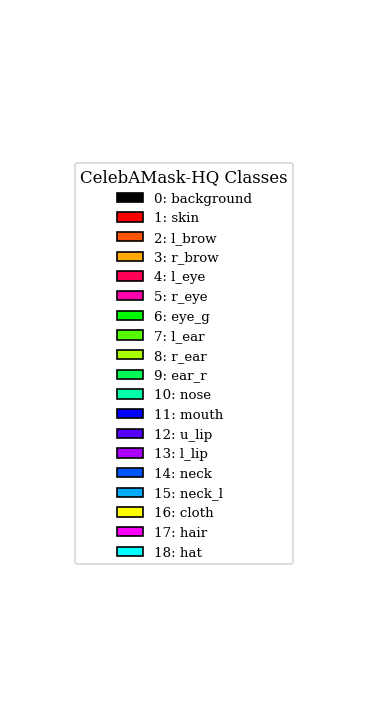

In [5]:
labels = [f"{i}: {name}" for i, name in enumerate(CLASS_NAMES)]

fig, ax = plt.subplots(figsize=(3.2, len(CLASS_NAMES) * 0.3 + 0.5))
ax.axis("off")

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color, edgecolor="black")
    for color in SEG_HEX
]

ax.legend(
    handles,
    labels,
    title="CelebAMask-HQ Classes",
    loc="center",
    frameon=True,
    fontsize=8,
    title_fontsize=10,
    ncol=1,
)

plt.tight_layout()
plt.savefig("fig_seg_class_legend.pdf", bbox_inches="tight")
plt.show()

## 2. Baseline Inference Results (Clean Images)

BiSeNet on official test split (IDs 28000–29999), no noise.

**Pixel accuracy vs Mean class accuracy:**
- *Pixel accuracy* = correct pixels / total pixels — dominated by large classes (background, skin, hair)
- *Mean class accuracy* = average accuracy per class — treats all 19 classes equally regardless of size
- A class that occupies 1% of pixels contributes equally to mean class accuracy but barely affects pixel accuracy

In [6]:
m_base = load_json(BASELINE_DIR / 'metrics.json')
if m_base is None:
    print('Baseline metrics not found. Run: sbatch server_scripts/submit_seg_baseline_celebahq.sh')
else:
    print(f"Test images:      {m_base['n_images']:,}  (IDs {m_base['test_ids']})")
    print(f"Pixel accuracy:   {m_base['pixel_accuracy']*100:.2f}%")
    print(f"Mean class acc:   {m_base['mean_class_accuracy']*100:.2f}%")
    print(f"mIoU:             {m_base['miou']*100:.2f}%")

    # Per-class table
    pc = m_base.get('per_class', {})
    rows = []
    for cls_name in CLASS_NAMES:
        v = pc.get(cls_name, {})
        rows.append({
            'Class':        cls_name,
            'IoU (%)':      round(v['iou']*100, 1) if v.get('iou') is not None else float('nan'),
            'Accuracy (%)': round(v['accuracy']*100, 1) if v.get('accuracy') is not None else float('nan'),
            'GT pixels':    v.get('gt_pixels', 0),
        })
    base_class_df = pd.DataFrame(rows)

    # Summary row
    summary = pd.DataFrame([{
        'Class': 'OVERALL',
        'IoU (%)': round(m_base['miou']*100, 1),
        'Accuracy (%)': round(m_base['mean_class_accuracy']*100, 1),
        'GT pixels': base_class_df['GT pixels'].sum(),
    }])
    display_df = pd.concat([base_class_df, summary], ignore_index=True)

    styled = display_df.style \
        .format({'IoU (%)': '{:.1f}', 'Accuracy (%)': '{:.1f}', 'GT pixels': '{:,}'}) \
        .background_gradient(subset=['IoU (%)','Accuracy (%)'], cmap='Blues', vmin=0, vmax=100) \
        .set_caption('Baseline: BiSeNet on clean test images (no noise)')
    display(styled)

Test images:      100  (IDs 28000–28099)
Pixel accuracy:   95.31%
Mean class acc:   81.38%
mIoU:             71.51%


,Class,IoU (%),Accuracy (%),GT pixels
0,background,93.7,96.2,"8,273,108"
1,skin,93.4,96.4,"6,660,500"
2,l_brow,65.4,81.3,"104,119"
3,r_brow,63.1,78.8,"96,267"
4,l_eye,64.1,79.3,"50,972"
5,r_eye,61.6,75.6,"48,886"
6,eye_g,63.5,96.3,"60,223"
7,l_ear,67.5,79.1,"127,679"
8,r_ear,68.0,81.6,"106,139"
9,ear_r,32.6,38.0,"40,989"


### Figure — Baseline Per-Class IoU and Accuracy

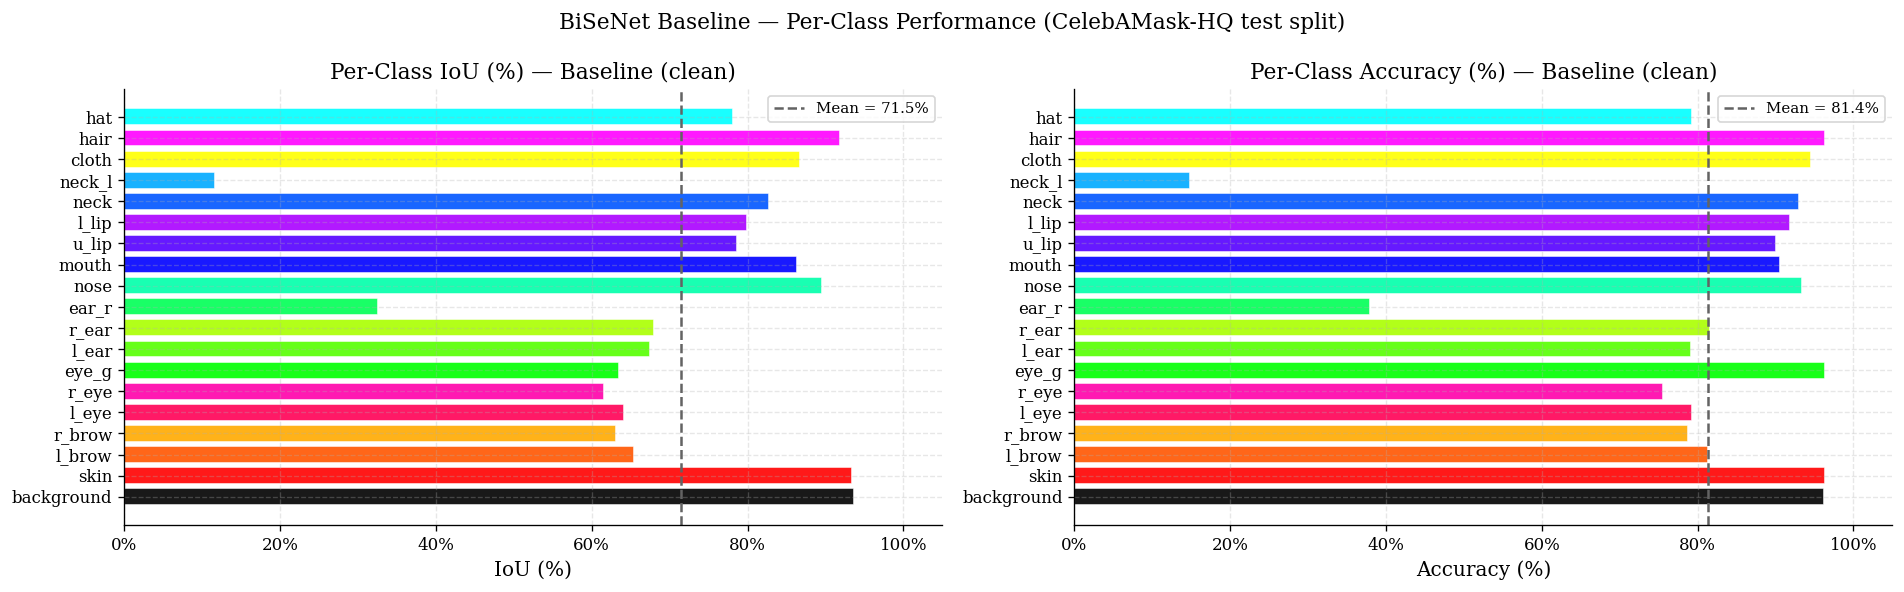

In [7]:
if m_base is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, metric, label in zip(axes, ['IoU (%)', 'Accuracy (%)'],
                                  ['IoU (%)', 'Accuracy (%)']):
        sub = base_class_df.copy()
        colors_bar = [SEG_HEX[CLASS_NAMES.index(c)] if c in CLASS_NAMES else '#aaa'
                      for c in sub['Class']]
        ax.barh(sub['Class'], sub[metric], color=colors_bar, edgecolor='white', alpha=0.9)
        ax.axvline(sub[metric].mean(), color='#636363', lw=1.5, ls='--',
                   label=f'Mean = {sub[metric].mean():.1f}%')
        ax.set_xlabel(label)
        ax.set_xlim(0, 105)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_title(f'Per-Class {label} — Baseline (clean)')
        ax.legend(fontsize=9)

    fig.suptitle('BiSeNet Baseline — Per-Class Performance (CelebAMask-HQ test split)',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_baseline_per_class.pdf', bbox_inches='tight')
    plt.show()

## 3. Load Certification Results (ISO + Manifold)

In [10]:
cert_rows = []
per_class_rows = []

MODES = {
    'Isotropic': 'pixel_isotropic',
    'Manifold':  'pixel_manifold',
}

for smoothing, mode_dir_name in MODES.items():
    mode_dir = CERTIFY_DIR / mode_dir_name
    if not mode_dir.exists():
        print(f'  MISSING: {mode_dir}')
        continue
    for s in SIGMA_VALUES:
        m = load_json(mode_dir / sigma_tag(s) / 'metrics.json')
        if m is None: continue

        # certified radius from formula
        tau = m.get('smoothing', {}).get('tau', 0.75)
        radius = float(s) * _norm.ppf(tau)

        cert_rows.append({
            'Smoothing':              smoothing,
            'σ':                      float(s),
            'R = σΦ⁻¹(τ)':           round(radius, 4),
            'Pixel acc (%)':          round(m.get('mean_pixel_acc', np.nan)*100, 2),
            'Cert pixel acc (%)':     round(m.get('mean_certified_pixel_acc', np.nan)*100, 2),
            'mIoU (%)':               round(m.get('mean_miou', np.nan)*100, 2),
            'Cert mIoU (%)':          round(m.get('mean_certified_miou', np.nan)*100, 2),
            'Abstain rate (%)':       round(m.get('mean_abstain_rate', np.nan)*100, 2),
            'N test':                 m.get('total_test_samples', np.nan),
        })

        # Per-class mIoU from metrics.json
        pc_iou = m.get('mean_iou_per_class', {})
        for cls_name in CLASS_NAMES:
            per_class_rows.append({
                'Smoothing': smoothing,
                'σ':         float(s),
                'Class':     cls_name,
                'IoU (%)':   round(pc_iou.get(cls_name, np.nan)*100, 2),
            })

cert_df    = pd.DataFrame(cert_rows)
pc_iou_df  = pd.DataFrame(per_class_rows)

if cert_df.empty:
    print('No certification results found. Run submit_seg_sigma_quad.sh first.')
else:
    print(f'Rows: {len(cert_df)}  Modes: {cert_df.Smoothing.unique().tolist()}')
    print(f'Sigmas found: {sorted(cert_df["σ"].unique().tolist())}')
    display(cert_df)

Rows: 19  Modes: ['Isotropic', 'Manifold']
Sigmas found: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


,Smoothing,σ,R = σΦ⁻¹(τ),Pixel acc (%),Cert pixel acc (%),mIoU (%),Cert mIoU (%),Abstain rate (%),N test
0,Isotropic,0.1,0.0674,93.65,96.07,66.86,67.91,5.86,100
1,Isotropic,0.2,0.1349,90.07,94.43,54.93,54.54,11.24,100
2,Isotropic,0.3,0.2023,80.82,89.72,37.77,41.08,23.61,100
3,Isotropic,0.4,0.2698,57.08,72.12,18.96,23.12,42.77,100
4,Isotropic,0.5,0.3372,38.26,47.53,7.82,11.35,40.01,100
5,Isotropic,0.6,0.4047,32.46,36.50,3.63,4.51,24.51,100
6,Isotropic,0.7,0.4721,31.27,32.07,2.68,2.84,13.15,100
7,Isotropic,0.8,0.5396,30.77,30.59,2.43,2.45,8.55,100
8,Isotropic,0.9,0.6070,30.43,29.96,2.36,2.27,8.06,100
9,Isotropic,1.0,0.6745,30.01,29.59,2.30,2.23,8.80,100


## ~~Corrected metrics from results.csv~~ (DISABLED — rerun certification instead)

**This cell was used to manually correct `certified_pixel_acc` from old results.csv.**

After rerunning certification the formulas are fixed in code:
- `certified_pixel_acc` = (certified ∩ correct) / **all pixels**
- `certified_miou` = IoU where abstained → pred=−1 (hurts union)

**Just rerun:** `./server_scripts/submit_seg_sigma_quad.sh` after deleting old metrics.

## 4. Summary Tables per Mode

In [11]:
if not cert_df.empty:
    for smoothing in ['Isotropic', 'Manifold']:
        sub = cert_df[cert_df['Smoothing'] == smoothing].copy()
        if sub.empty: continue
        print(f'\n{"="*70}')
        print(f'{smoothing} Smoothing Results')
        print(f'{"="*70}')
        cols = ['σ','R = σΦ⁻¹(τ)','Pixel acc (%)','Cert pixel acc (%)',
                'mIoU (%)','Cert mIoU (%)','Abstain rate (%)']
        display(sub[cols].style
            .format({c: '{:.2f}' for c in cols[2:]})
            .background_gradient(subset=['Cert pixel acc (%)','Cert mIoU (%)'],
                                 cmap='Blues', vmin=0, vmax=100)
            .background_gradient(subset=['Abstain rate (%)'],
                                 cmap='Reds_r', vmin=0, vmax=30)
            .set_caption(f'{smoothing} — Certified Segmentation Results'))


Isotropic Smoothing Results


,σ,R = σΦ⁻¹(τ),Pixel acc (%),Cert pixel acc (%),mIoU (%),Cert mIoU (%),Abstain rate (%)
0,0.100000,0.067400,93.65,96.07,66.86,67.91,5.86
1,0.200000,0.134900,90.07,94.43,54.93,54.54,11.24
2,0.300000,0.202300,80.82,89.72,37.77,41.08,23.61
3,0.400000,0.269800,57.08,72.12,18.96,23.12,42.77
4,0.500000,0.337200,38.26,47.53,7.82,11.35,40.01
5,0.600000,0.404700,32.46,36.50,3.63,4.51,24.51
6,0.700000,0.472100,31.27,32.07,2.68,2.84,13.15
7,0.800000,0.539600,30.77,30.59,2.43,2.45,8.55
8,0.900000,0.607000,30.43,29.96,2.36,2.27,8.06
9,1.000000,0.674500,30.01,29.59,2.30,2.23,8.80



Manifold Smoothing Results


,σ,R = σΦ⁻¹(τ),Pixel acc (%),Cert pixel acc (%),mIoU (%),Cert mIoU (%),Abstain rate (%)
10,0.100000,0.067400,72.80,72.85,43.59,43.63,0.21
11,0.200000,0.134900,72.80,72.92,43.59,43.68,0.44
12,0.300000,0.202300,72.81,72.98,43.59,43.74,0.66
13,0.400000,0.269800,72.81,73.05,43.60,43.78,0.89
14,0.500000,0.337200,72.81,73.11,43.60,43.88,1.12
15,0.600000,0.404700,72.82,73.17,43.60,43.92,1.34
16,0.700000,0.472100,72.82,73.24,43.61,43.96,1.57
17,0.800000,0.539600,72.82,73.30,43.61,44.04,1.80
18,0.900000,0.607000,72.83,73.36,43.61,44.11,2.03


## 5. Figure — Pixel Accuracy & Certified Pixel Accuracy vs σ

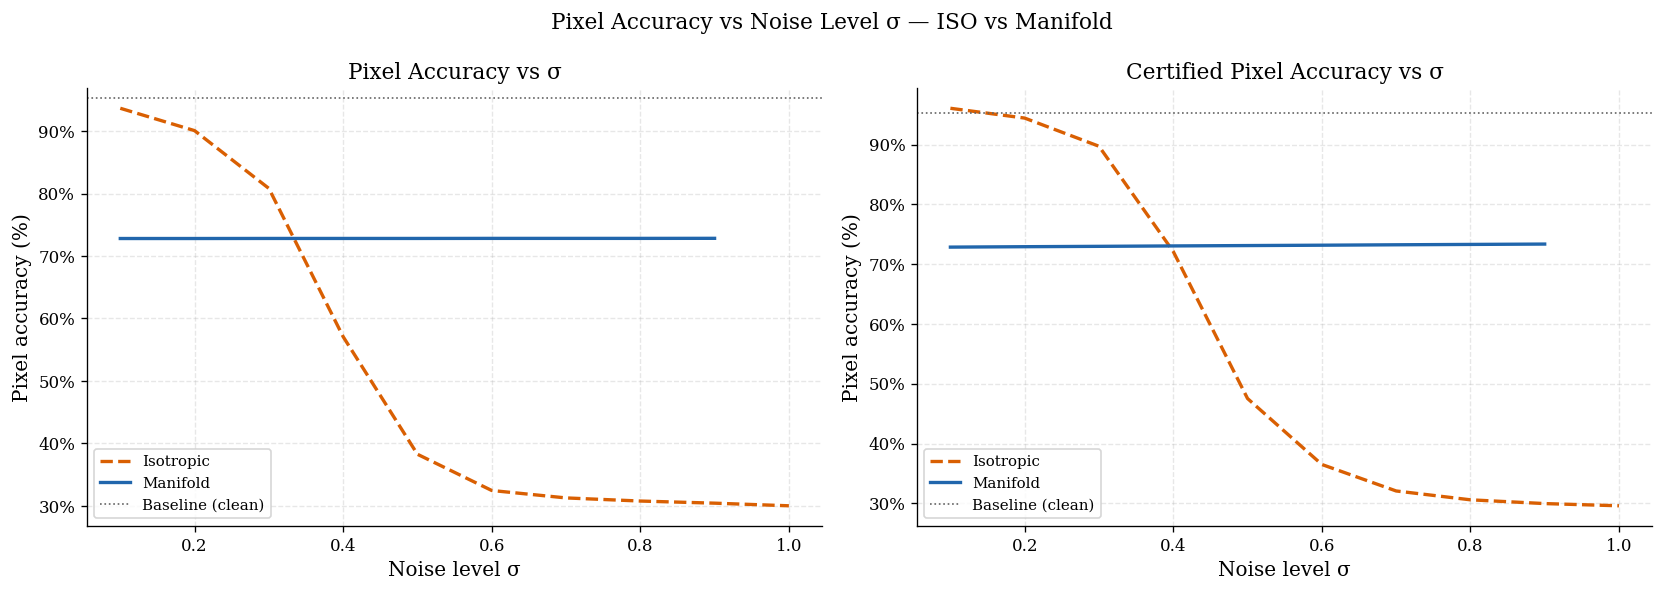

In [12]:
if not cert_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for smoothing, grp in cert_df.groupby('Smoothing'):
        grp = grp.sort_values('σ')
        axes[0].plot(grp['σ'], grp['Pixel acc (%)'],
                     color=COL[smoothing], ls=LS[smoothing], lw=2, label=smoothing)
        axes[1].plot(grp['σ'], grp['Cert pixel acc (%)'],
                     color=COL[smoothing], ls=LS[smoothing], lw=2, label=smoothing)

    # Baseline reference line
    if m_base is not None:
        for ax in axes:
            ax.axhline(m_base['pixel_accuracy']*100, color='#636363', lw=1,
                       ls=':', label='Baseline (clean)')

    axes[0].set_title('Pixel Accuracy vs σ')
    axes[1].set_title('Certified Pixel Accuracy vs σ')
    for ax in axes:
        ax.set_xlabel('Noise level σ')
        ax.set_ylabel('Pixel accuracy (%)')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend()

    fig.suptitle('Pixel Accuracy vs Noise Level σ — ISO vs Manifold', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_seg_pixel_acc.pdf', bbox_inches='tight')
    plt.show()

## 6. Figure — mIoU & Certified mIoU vs σ

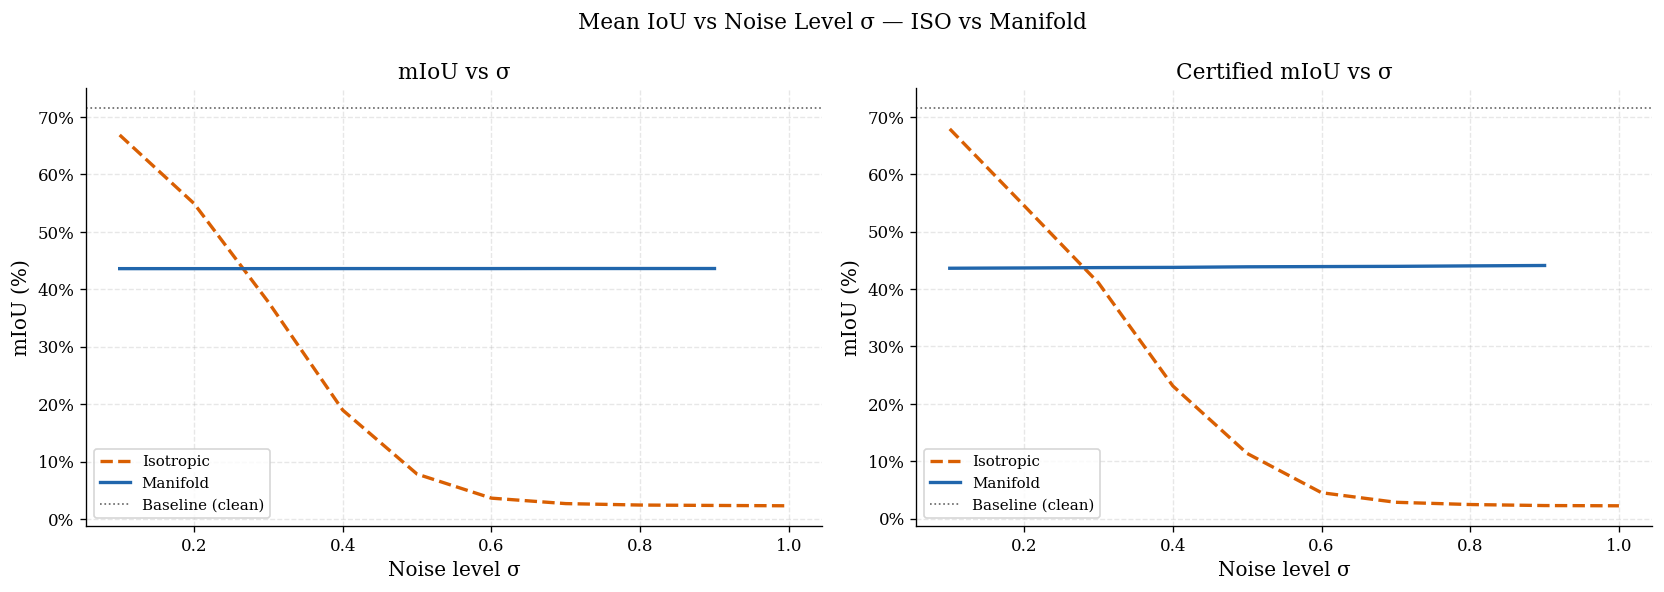

In [13]:
if not cert_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for smoothing, grp in cert_df.groupby('Smoothing'):
        grp = grp.sort_values('σ')
        axes[0].plot(grp['σ'], grp['mIoU (%)'],
                     color=COL[smoothing], ls=LS[smoothing], lw=2, label=smoothing)
        axes[1].plot(grp['σ'], grp['Cert mIoU (%)'],
                     color=COL[smoothing], ls=LS[smoothing], lw=2, label=smoothing)

    if m_base is not None:
        for ax in axes:
            ax.axhline(m_base['miou']*100, color='#636363', lw=1, ls=':', label='Baseline (clean)')

    axes[0].set_title('mIoU vs σ')
    axes[1].set_title('Certified mIoU vs σ')
    for ax in axes:
        ax.set_xlabel('Noise level σ')
        ax.set_ylabel('mIoU (%)')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend()

    fig.suptitle('Mean IoU vs Noise Level σ — ISO vs Manifold', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_seg_miou.pdf', bbox_inches='tight')
    plt.show()

## 7. Figure — Certified Radius vs σ

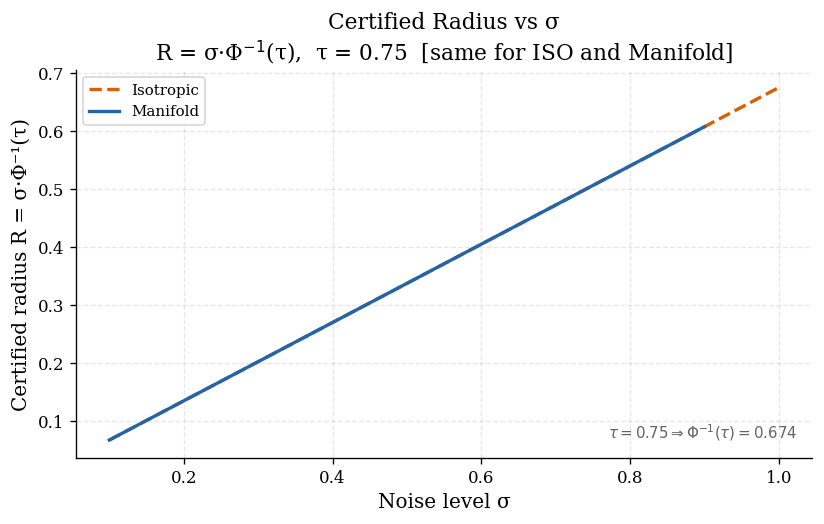

In [14]:
if not cert_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    # R = σ·Φ⁻¹(τ) — same formula for both ISO and Manifold, so only one line needed
    # But we plot both to confirm they overlap
    for smoothing, grp in cert_df.groupby('Smoothing'):
        grp = grp.sort_values('σ')
        ax.plot(grp['σ'], grp['R = σΦ⁻¹(τ)'],
                color=COL[smoothing], ls=LS[smoothing], lw=2, label=smoothing)

    ax.set_xlabel('Noise level σ')
    ax.set_ylabel('Certified radius R = σ·Φ⁻¹(τ)')
    ax.set_title('Certified Radius vs σ\n'
                 r'R = σ·Φ$^{-1}$(τ),  τ = 0.75  [same for ISO and Manifold]')
    ax.legend()
    ax.text(0.98, 0.05, r'$\tau=0.75 \Rightarrow \Phi^{-1}(\tau)=0.674$',
            transform=ax.transAxes, ha='right', fontsize=9, color='#636363')
    plt.tight_layout()
    plt.savefig('fig_seg_radius.pdf', bbox_inches='tight')
    plt.show()

## 8. Figure — Abstain Rate vs σ

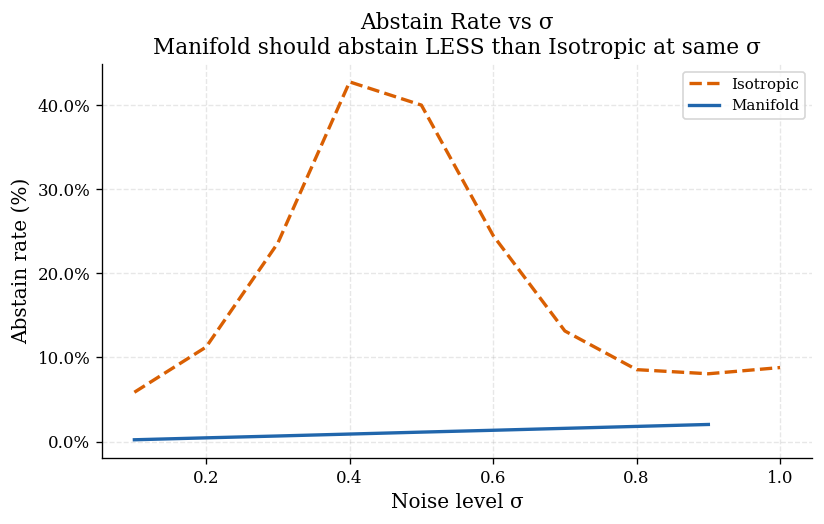

In [15]:
if not cert_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for smoothing, grp in cert_df.groupby('Smoothing'):
        grp = grp.sort_values('σ')
        ax.plot(grp['σ'], grp['Abstain rate (%)'],
                color=COL[smoothing], ls=LS[smoothing], lw=2, label=smoothing)

    ax.set_xlabel('Noise level σ')
    ax.set_ylabel('Abstain rate (%)')
    ax.set_title('Abstain Rate vs σ\n'
                 'Manifold should abstain LESS than Isotropic at same σ')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_seg_abstain.pdf', bbox_inches='tight')
    plt.show()

## 9. Figure — Combined 4-Panel Summary

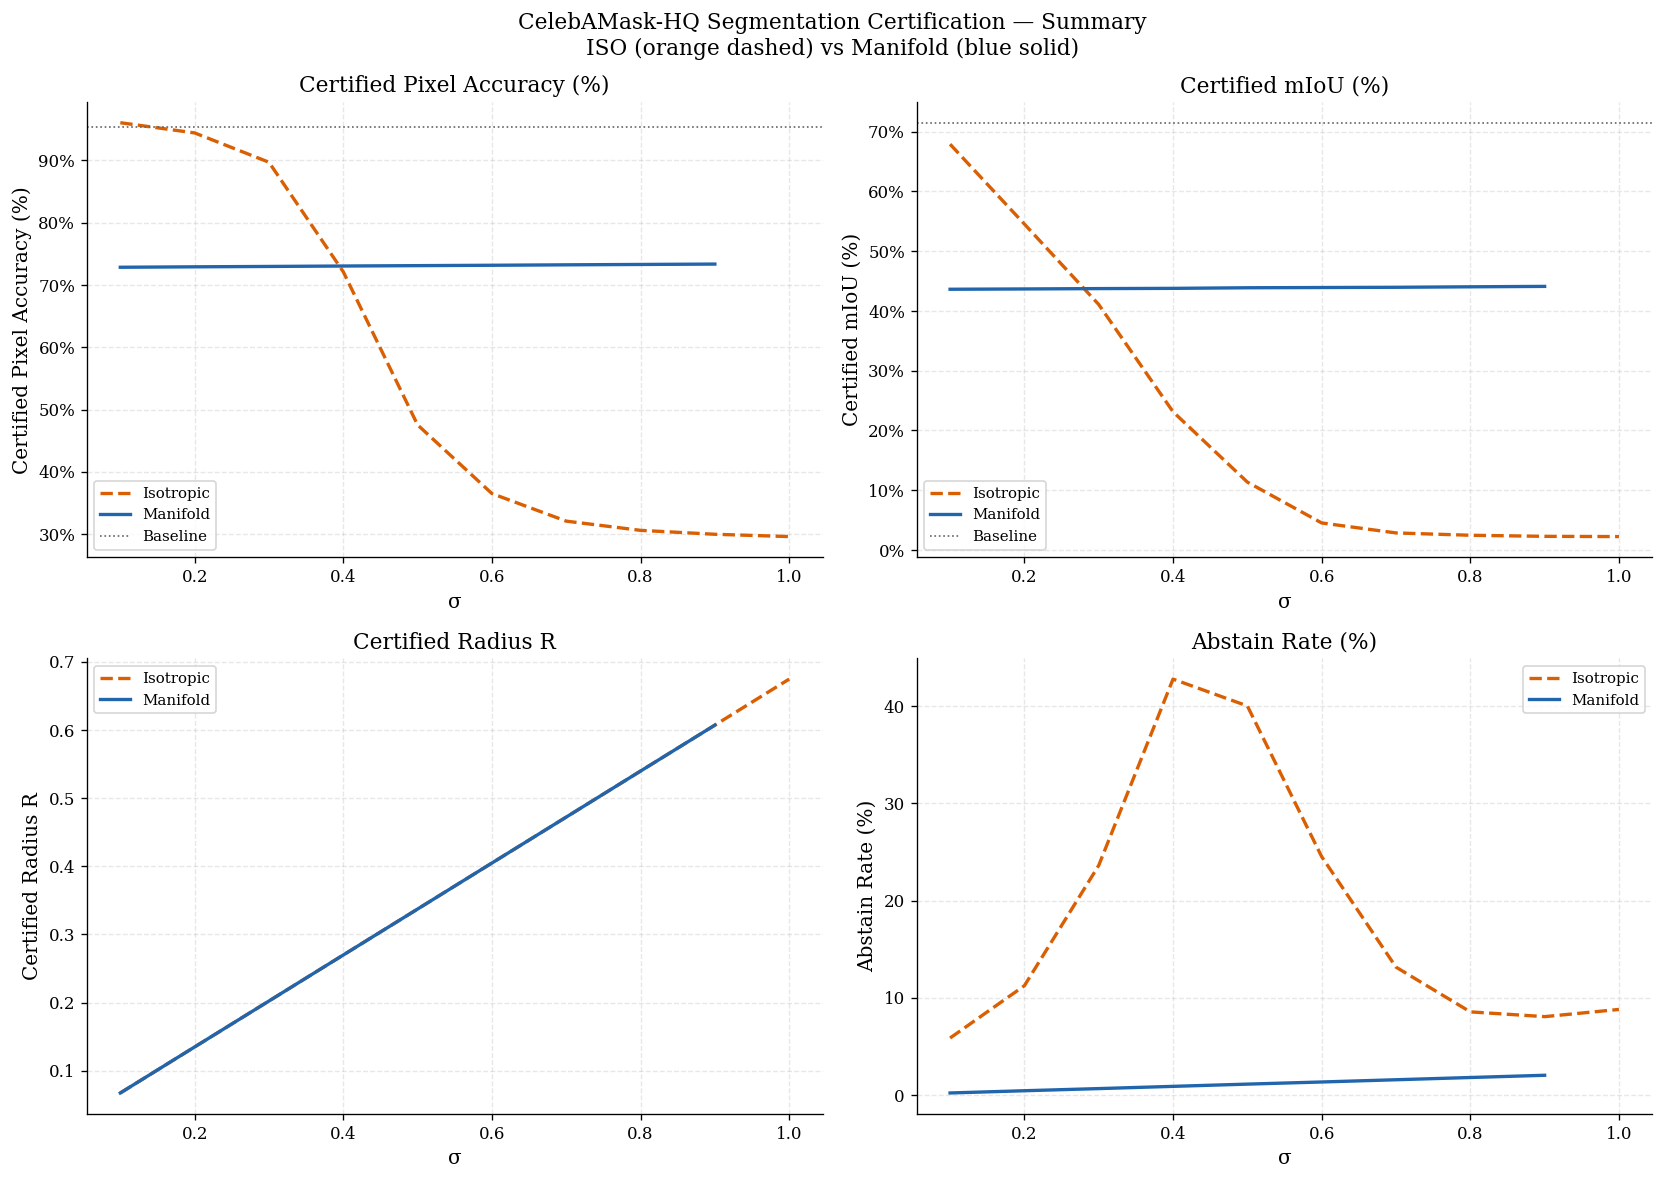

In [16]:
if not cert_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    panels = [
        (axes[0,0], 'Cert pixel acc (%)', 'Certified Pixel Accuracy (%)', True),
        (axes[0,1], 'Cert mIoU (%)',       'Certified mIoU (%)',           True),
        (axes[1,0], 'R = σΦ⁻¹(τ)',         'Certified Radius R',           False),
        (axes[1,1], 'Abstain rate (%)',     'Abstain Rate (%)',             False),
    ]

    for ax, col, ylabel, is_pct in panels:
        for smoothing, grp in cert_df.groupby('Smoothing'):
            grp = grp.sort_values('σ')
            ax.plot(grp['σ'], grp[col],
                    color=COL[smoothing], ls=LS[smoothing], lw=2, label=smoothing)
        ax.set_xlabel('σ')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        if is_pct:
            ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend()

    # Add baseline reference to accuracy panels
    if m_base is not None:
        axes[0,0].axhline(m_base['pixel_accuracy']*100, color='#636363', lw=1, ls=':', label='Baseline')
        axes[0,1].axhline(m_base['miou']*100,           color='#636363', lw=1, ls=':', label='Baseline')
        axes[0,0].legend()
        axes[0,1].legend()

    fig.suptitle('CelebAMask-HQ Segmentation Certification — Summary\n'
                 'ISO (orange dashed) vs Manifold (blue solid)',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_seg_summary_4panel.pdf', bbox_inches='tight')
    plt.show()

## 10. Per-Class IoU Tables (σ as rows)

In [17]:
if not pc_iou_df.empty:
    for smoothing in ['Isotropic', 'Manifold']:
        sub = pc_iou_df[pc_iou_df['Smoothing'] == smoothing]
        if sub.empty: continue

        # Pivot: rows=σ, columns=class
        pivot = sub.pivot(index='σ', columns='Class', values='IoU (%)')
        # Reorder columns to match CLASS_NAMES order
        pivot = pivot[[c for c in CLASS_NAMES if c in pivot.columns]]
        pivot['mIoU'] = pivot.mean(axis=1).round(2)

        print(f'\n{"="*80}')
        print(f'Per-Class IoU (%) — {smoothing}  |  rows=σ, columns=class')
        print(f'{"="*80}')
        styled = pivot.style \
            .format('{:.1f}') \
            .background_gradient(cmap='Blues', vmin=0, vmax=100) \
            .set_caption(f'Per-Class IoU (%) — {smoothing}')
        display(styled)


Per-Class IoU (%) — Isotropic  |  rows=σ, columns=class


Class,background,skin,l_brow,r_brow,l_eye,r_eye,eye_g,l_ear,r_ear,ear_r,nose,mouth,u_lip,l_lip,neck,neck_l,cloth,hair,hat,mIoU
σ,,,,,,,,,,,,,,,,,,,,
0.100000,90.2,92.1,49.2,44.7,54.1,52.5,70.7,40.8,40.1,16.2,87.5,78.0,74.9,78.2,71.0,1.9,60.2,86.3,63.6,60.6
0.200000,84.8,88.4,29.3,29.8,23.2,29.2,46.3,20.4,24.5,8.9,84.4,71.6,67.1,70.8,61.8,2.4,52.5,78.6,83.6,50.4
0.300000,75.4,79.7,7.0,12.1,3.6,8.5,14.3,9.1,7.9,5.0,70.6,49.0,45.5,47.8,48.1,0.1,34.5,57.2,33.4,32.0
0.400000,56.1,57.0,0.5,3.9,0.7,1.9,0.0,5.6,2.6,0.0,29.5,19.2,21.1,18.1,26.6,0.0,16.9,17.1,3.7,14.8
0.500000,39.6,24.1,0.0,0.5,0.0,0.7,0.0,0.6,0.7,0.0,5.2,5.4,6.6,6.6,9.6,0.0,10.2,1.2,0.1,5.8
0.600000,33.2,5.3,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.2,0.2,0.8,1.0,1.7,0.0,7.0,0.1,0.0,2.6
0.700000,31.5,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,3.2,0.0,0.0,1.9
0.800000,31.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.7,0.0,0.0,1.7
0.900000,30.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.2,0.0,0.0,1.7



Per-Class IoU (%) — Manifold  |  rows=σ, columns=class


Class,background,skin,l_brow,r_brow,l_eye,r_eye,eye_g,l_ear,r_ear,ear_r,nose,mouth,u_lip,l_lip,neck,neck_l,cloth,hair,hat,mIoU
σ,,,,,,,,,,,,,,,,,,,,
0.100000,53.6,77.8,33.0,29.9,39.9,40.3,0.0,7.5,9.4,0.0,78.3,29.2,44.9,50.2,48.2,0.0,17.3,55.3,0.0,32.4
0.200000,53.6,77.8,33.0,29.9,39.9,40.3,0.0,7.6,9.4,0.0,78.3,29.2,44.9,50.2,48.3,0.0,17.3,55.3,0.0,32.4
0.300000,53.6,77.8,33.0,29.9,39.9,40.3,0.0,7.6,9.4,0.0,78.3,29.2,44.9,50.2,48.3,0.0,17.3,55.3,0.0,32.4
0.400000,53.7,77.8,33.0,29.9,39.9,40.3,0.0,7.6,9.4,0.0,78.3,29.2,44.9,50.2,48.3,0.0,17.3,55.3,0.0,32.4
0.500000,53.7,77.8,33.0,29.9,40.0,40.3,0.0,7.6,9.4,0.0,78.3,29.2,44.9,50.2,48.3,0.0,17.3,55.3,0.0,32.4
0.600000,53.7,77.8,33.0,29.9,40.0,40.3,0.0,7.6,9.4,0.0,78.3,29.2,45.0,50.2,48.3,0.0,17.3,55.3,0.0,32.4
0.700000,53.7,77.8,33.0,30.0,40.0,40.3,0.0,7.6,9.4,0.0,78.3,29.2,44.9,50.2,48.3,0.0,17.3,55.3,0.0,32.4
0.800000,53.7,77.8,33.0,30.0,40.0,40.3,0.0,7.6,9.4,0.0,78.3,29.2,45.0,50.2,48.3,0.0,17.3,55.3,0.0,32.4
0.900000,53.7,77.8,33.1,30.0,40.0,40.3,0.0,7.6,9.4,0.0,78.3,29.2,45.0,50.2,48.3,0.0,17.3,55.3,0.0,32.4


## 11. Figure — Per-Class IoU vs σ (ISO vs Manifold)

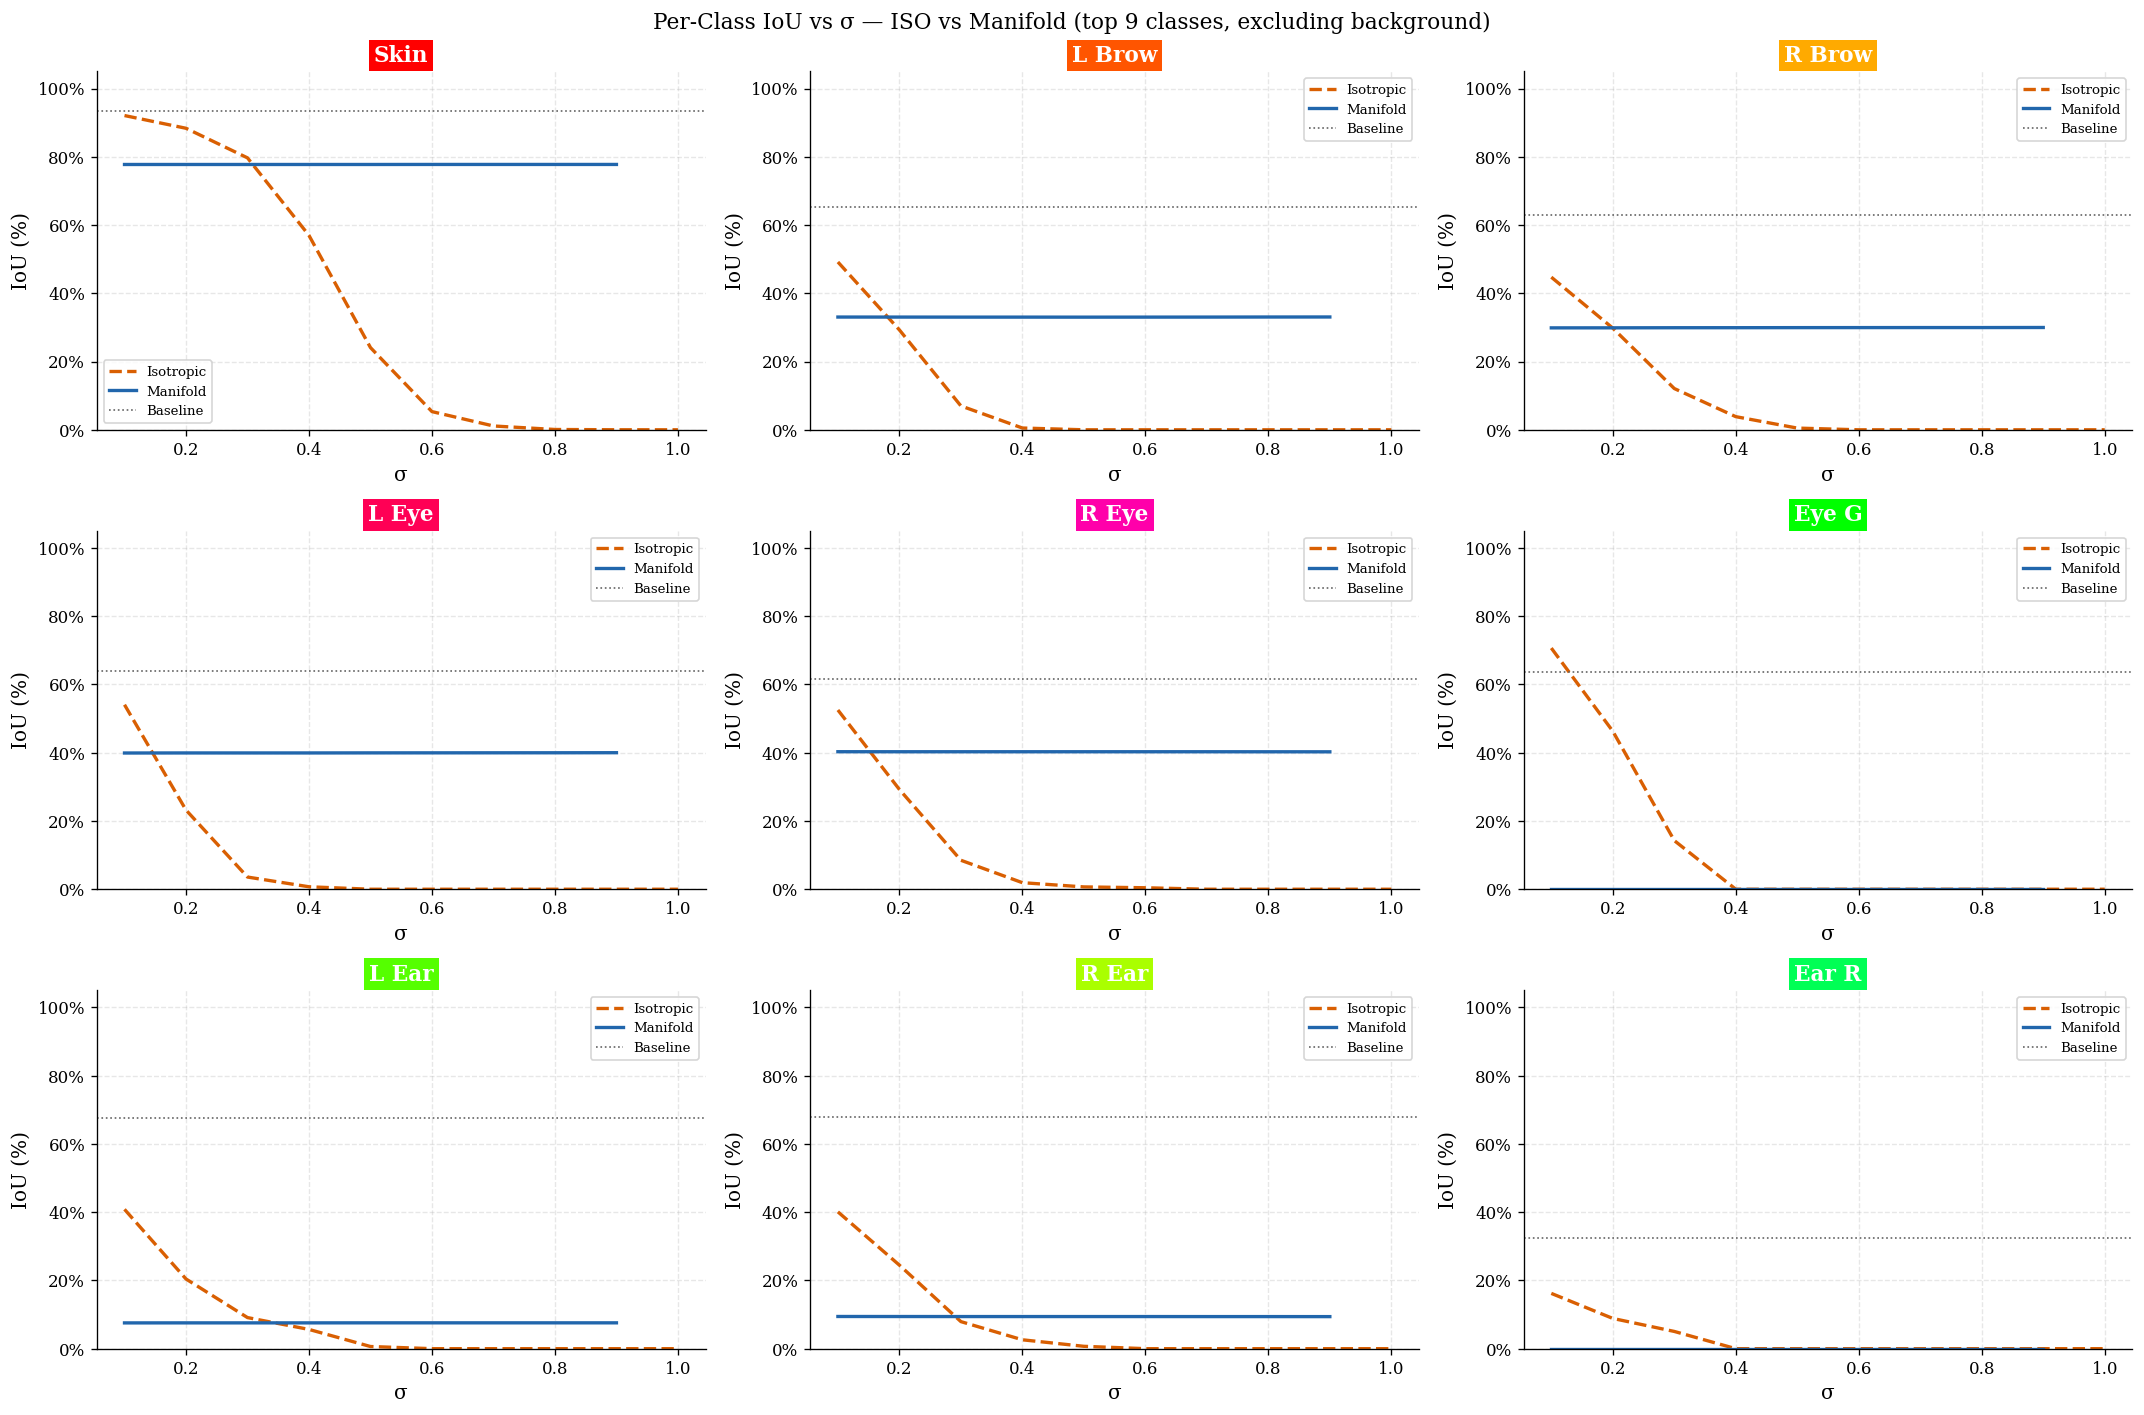

In [18]:
if not pc_iou_df.empty:
    # Show top 9 most common classes (skip background for clarity)
    top_classes = [c for c in CLASS_NAMES if c != 'background'][:9]
    ncols = 3
    nrows = int(np.ceil(len(top_classes) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows),
                             sharey=False, squeeze=False)

    for i, cls_name in enumerate(top_classes):
        ax = axes[i // ncols][i % ncols]
        cls_hex = SEG_HEX[CLASS_NAMES.index(cls_name)]

        for smoothing, grp in pc_iou_df[pc_iou_df['Class'] == cls_name].groupby('Smoothing'):
            grp = grp.sort_values('σ')
            ax.plot(grp['σ'], grp['IoU (%)'],
                    color=COL[smoothing], ls=LS[smoothing], lw=2, label=smoothing)

        # Baseline IoU for this class
        if m_base is not None:
            b_iou = m_base.get('per_class', {}).get(cls_name, {}).get('iou')
            if b_iou is not None:
                ax.axhline(b_iou*100, color='#636363', lw=1, ls=':', label='Baseline')

        # Coloured title patch
        ax.set_title(cls_name.replace('_',' ').title(), fontweight='bold',
                     color='white',
                     bbox=dict(facecolor=cls_hex, edgecolor='none', pad=3))
        ax.set_xlabel('σ')
        ax.set_ylabel('IoU (%)')
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend(fontsize=8)

    for j in range(i+1, nrows*ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    fig.suptitle('Per-Class IoU vs σ — ISO vs Manifold (top 9 classes, excluding background)',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_seg_per_class_iou.pdf', bbox_inches='tight')
    plt.show()

## 12. Figure — Baseline vs Best Certified mIoU per Class

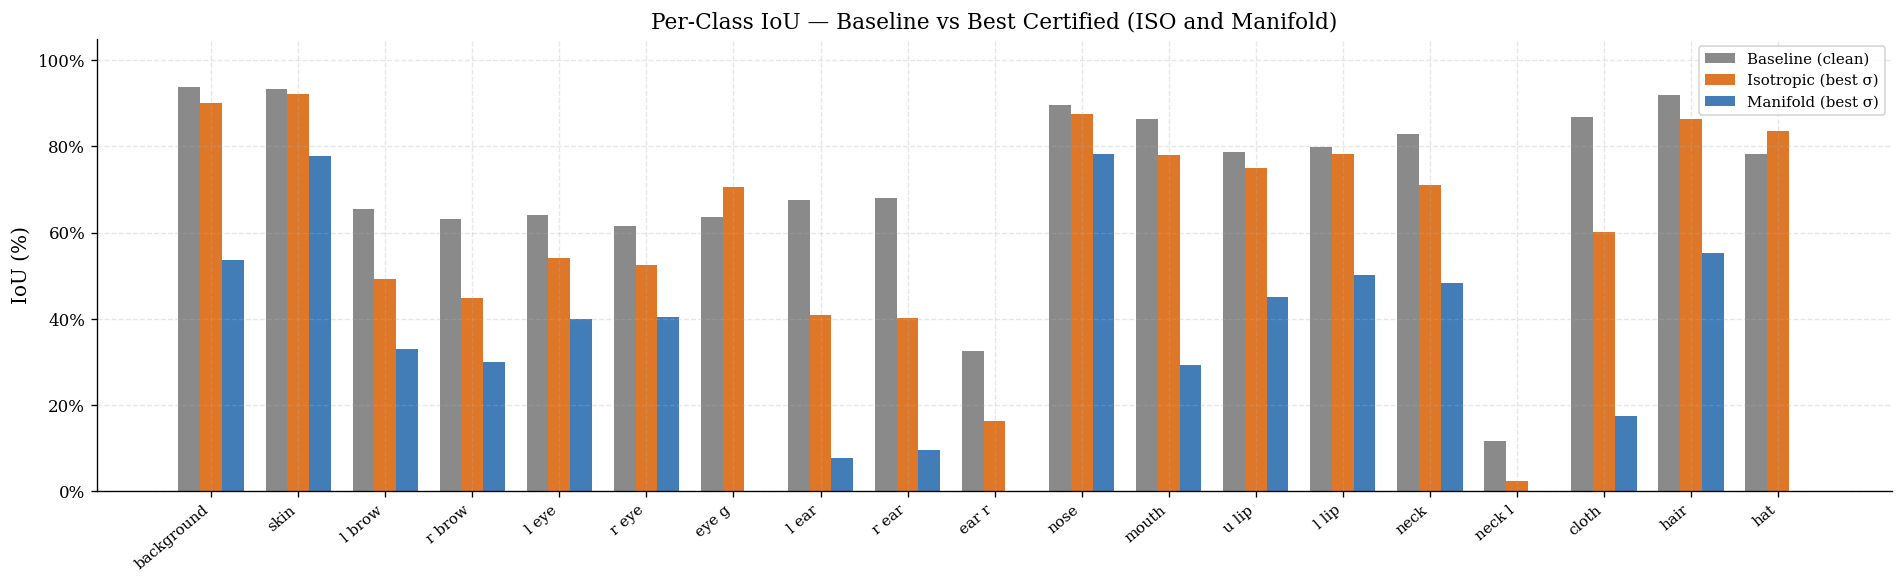

In [19]:
if not pc_iou_df.empty and m_base is not None:
    # Best certified IoU per class × smoothing (max over all σ)
    best_cert = pc_iou_df.groupby(['Smoothing','Class'])['IoU (%)'].max().reset_index()

    x = np.arange(len(CLASS_NAMES))
    w = 0.25

    fig, ax = plt.subplots(figsize=(16, 5))

    # Baseline bars
    base_iou = [m_base['per_class'].get(c, {}).get('iou', 0) or 0
                for c in CLASS_NAMES]
    ax.bar(x - w, [v*100 for v in base_iou], w,
           color='#636363', alpha=0.75, label='Baseline (clean)')

    for k, smoothing in enumerate(['Isotropic', 'Manifold']):
        sub = best_cert[best_cert['Smoothing']==smoothing].set_index('Class')
        vals = [sub['IoU (%)'].get(c, 0) for c in CLASS_NAMES]
        ax.bar(x + (k)*w, vals, w,
               color=COL[smoothing], alpha=0.85, label=f'{smoothing} (best σ)')

    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('_',' ') for c in CLASS_NAMES],
                       rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('IoU (%)')
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title('Per-Class IoU — Baseline vs Best Certified (ISO and Manifold)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_seg_baseline_vs_cert.pdf', bbox_inches='tight')
    plt.show()